In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('Full_Dataset_Cycling.csv')

In [3]:
df.head(5)

,Site_ID,Direction,Modus,Start_Time,End_Time,Count
0,Location_Tag_1,IN,FIETSERS,2019-08-01 00:00:00.0,2019-08-01 00:15:00.0,0.0
1,Location_Tag_1,IN,FIETSERS,2019-08-01 00:15:00.0,2019-08-01 00:30:00.0,0.0
2,Location_Tag_1,IN,FIETSERS,2019-08-01 00:30:00.0,2019-08-01 00:45:00.0,0.0
3,Location_Tag_1,IN,FIETSERS,2019-08-01 00:45:00.0,2019-08-01 01:00:00.0,0.0
4,Location_Tag_1,IN,FIETSERS,2019-08-01 01:00:00.0,2019-08-01 01:15:00.0,1.0


In [4]:
df.tail(5)

,Site_ID,Direction,Modus,Start_Time,End_Time,Count
42789169,Location_Tag_152,OUT,FIETSERS,2026-05-04 03:45:00.0,2026-05-04 04:00:00.0,0.0
42789170,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:00:00.0,2026-05-04 04:15:00.0,0.0
42789171,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:15:00.0,2026-05-04 04:30:00.0,0.0
42789172,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:30:00.0,2026-05-04 04:45:00.0,0.0
42789173,Location_Tag_152,OUT,FIETSERS,2026-05-04 04:45:00.0,2026-05-04 05:00:00.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42789174 entries, 0 to 42789173
Data columns (total 6 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Site_ID     object 
 1   Direction   object 
 2   Modus       object 
 3   Start_Time  object 
 4   End_Time    object 
 5   Count       float64
dtypes: float64(1), object(5)
memory usage: 1.9+ GB


In [7]:
df.isnull().sum()

Site_ID             0
Direction           0
Modus               0
Start_Time          0
End_Time            0
Count         1085221
dtype: int64

In [8]:
print(df["Site_ID"].nunique())
print(df["Direction"].value_counts())
print(df["Modus"].value_counts())

150
Direction
IN     21394587
OUT    21394587
Name: count, dtype: int64
Modus
FIETSERS       42766126
VOETGANGERS       23048
Name: count, dtype: int64


In [9]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["End_Time"] = pd.to_datetime(df["End_Time"])

SARIMA(p,d,q)(P,D,Q,s) <br>
(p,d,q) -> ARIMA <br>
(P,D,Q,s) -> seasonality <br>
p=1 -> use the value 1 before <br>
d=1 -> take the difference between the current value and the one before <br>
q=1 -> fix the current estimate by using the prediction error one before <br>
P=1 -> use the one cycle before <br>
D=1 -> take the difference between the current cycle and the one before <br>
Q=1 -> fix the current estimate by using the prediction error one cycle before <br>
s: how many of datapoints one cycle has <br>


### First, explore data for one site, one direction (Location_Tag_1, IN)

In [10]:
df_loc1_IN = df[(df["Site_ID"] == "Location_Tag_1") & (df["Direction"] == "IN")].reset_index(drop=True)

In [11]:
df_loc1_IN = df_loc1_IN.sort_values("Start_Time")
df_loc1_IN = df_loc1_IN.set_index("Start_Time")

In [12]:
df_loc1_IN.head()

,Site_ID,Direction,Modus,End_Time,Count
Start_Time,,,,,
2019-08-01 00:00:00,Location_Tag_1,IN,FIETSERS,2019-08-01 00:15:00,0.0
2019-08-01 00:15:00,Location_Tag_1,IN,FIETSERS,2019-08-01 00:30:00,0.0
2019-08-01 00:30:00,Location_Tag_1,IN,FIETSERS,2019-08-01 00:45:00,0.0
2019-08-01 00:45:00,Location_Tag_1,IN,FIETSERS,2019-08-01 01:00:00,0.0
2019-08-01 01:00:00,Location_Tag_1,IN,FIETSERS,2019-08-01 01:15:00,1.0


Aggregate by different time periods (yearly, quarterly, etc.) and explore trends

In [15]:
# yearly aggregate
df_loc1_IN_Y = df_loc1_IN.resample("YE").agg({"Count": "sum"})

# quarterly aggregate
df_loc1_IN_Q = df_loc1_IN.resample("QE").agg({"Count": "sum"})

# monthly aggregate
df_loc1_IN_M = df_loc1_IN.resample("ME").agg({"Count": "sum"})

# weekly aggregate
df_loc1_IN_W = df_loc1_IN.resample("W-MON").agg({"Count": "sum"})

# dayly aggregate
df_loc1_IN_D = df_loc1_IN.resample("D").agg({"Count": "sum"})

# hourly aggregate
df_loc1_IN_h = df_loc1_IN.resample("h").agg({"Count": "sum"})


<Axes: xlabel='Start_Time'>

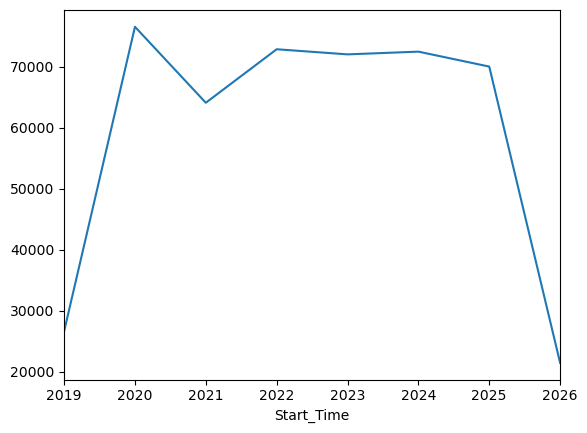

In [ ]:
# yearly
df_loc1_IN_Y["Count"].plot()

<Axes: xlabel='Start_Time'>

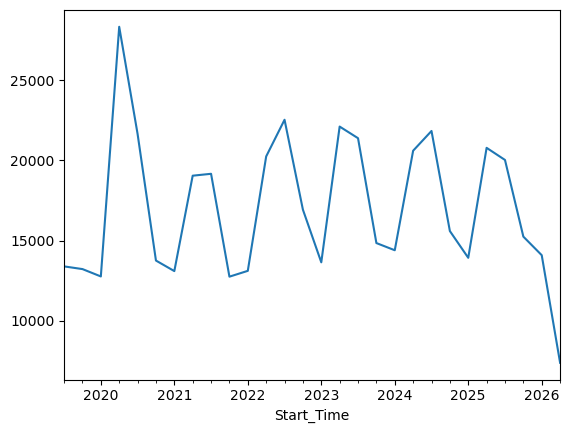

In [17]:
# quarterly
df_loc1_IN_Q["Count"].plot()

<Axes: xlabel='Start_Time'>

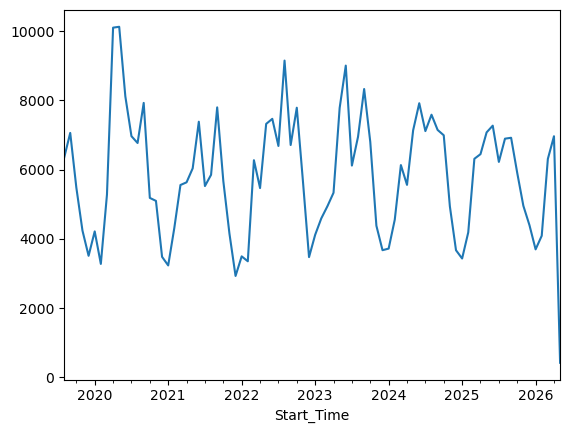

In [18]:
# monthly
df_loc1_IN_M["Count"].plot()

In [ ]:
# weekly
df_loc1_IN_W = df_loc1_IN_W.reset_index()

<Axes: xlabel='Start_Time'>

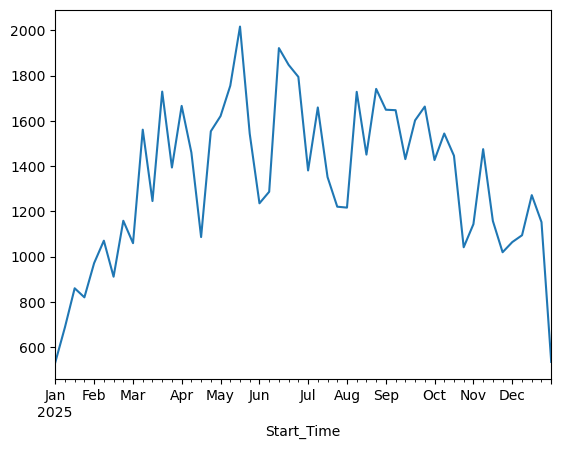

In [20]:
# year = 2025 only
df_loc1_IN_W[df_loc1_IN_W['Start_Time'].dt.year==2025].set_index("Start_Time")["Count"].plot()

In [21]:
# daily
df_loc1_IN_D = df_loc1_IN_D.reset_index()


<Axes: xlabel='Start_Time'>

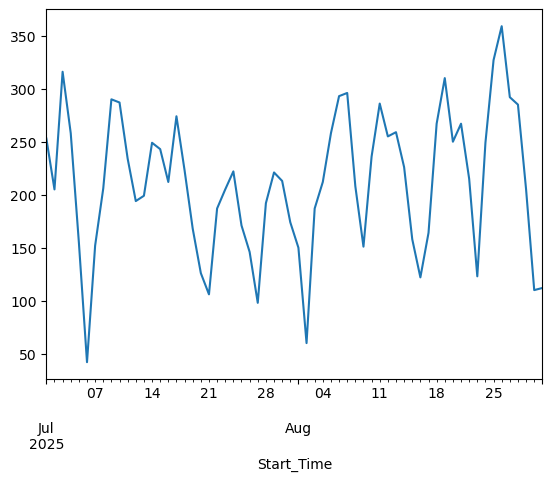

In [ ]:
# July/August 2025 only
df_loc1_IN_D[(df_loc1_IN_D['Start_Time'].dt.year==2025)&(df_loc1_IN_D['Start_Time'].dt.month.isin([7,8]))].set_index("Start_Time")["Count"].plot()

<Axes: xlabel='Start_Time'>

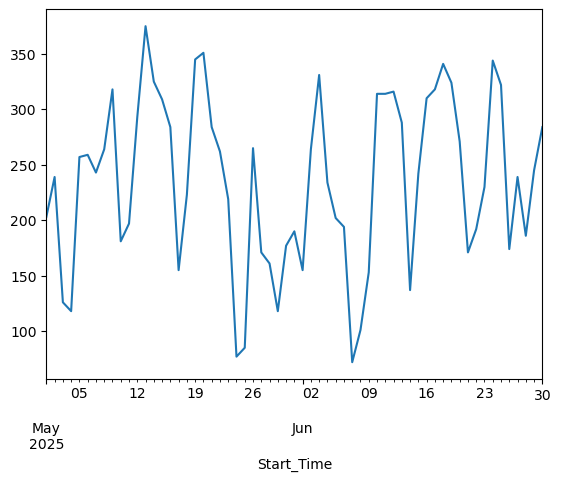

In [23]:
# May/June 2025 only
df_loc1_IN_D[(df_loc1_IN_D['Start_Time'].dt.year==2025)&(df_loc1_IN_D['Start_Time'].dt.month.isin([5,6]))].set_index("Start_Time")["Count"].plot()

In [24]:
# hourly
df_loc1_IN_h = df_loc1_IN_h.reset_index()

In [25]:
start = pd.Timestamp("2025-08-01")
end = pd.Timestamp("2025-08-14")

<Axes: xlabel='Start_Time'>

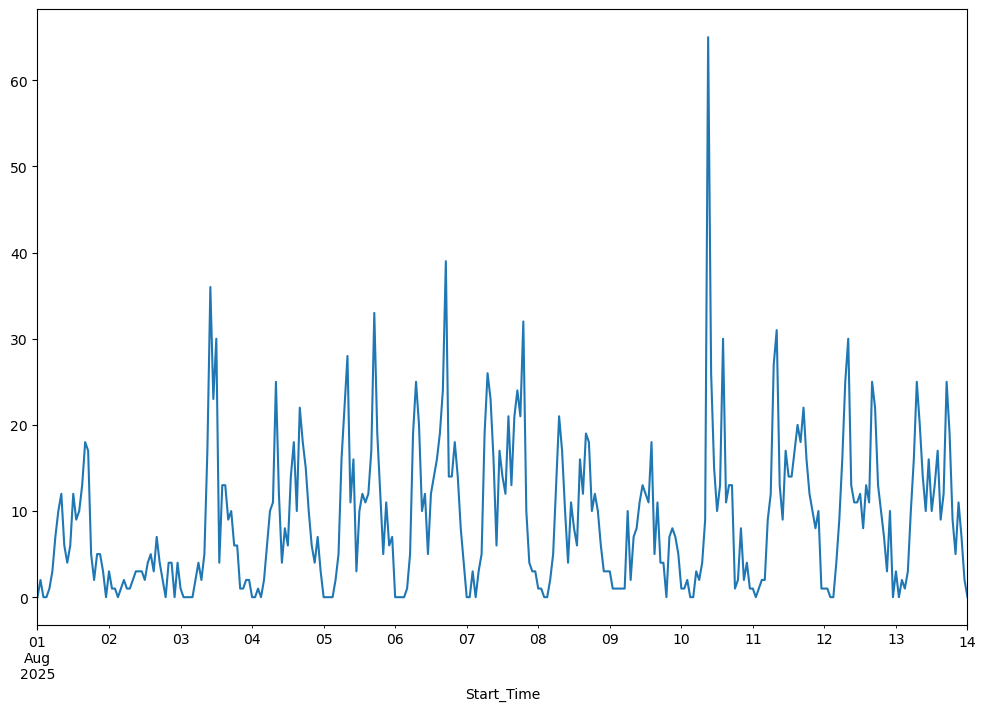

In [26]:
df_loc1_IN_h[(df_loc1_IN_h['Start_Time']>=start)&(df_loc1_IN_h['Start_Time']<=end)].set_index("Start_Time")["Count"].plot(figsize=(12,8))

1時間ごとに集計したデータに対して、SARIMAやってみるけど、データ多すぎるので、とりあえず直近6ヶ月分

In [34]:
df_log1_IN_h_6M = df_loc1_IN_h[(df_loc1_IN_h["Start_Time"].dt.year==2025)&(df_loc1_IN_h["Start_Time"].dt.month.isin([6,7,8,9,10,11,12]))].set_index('Start_Time')

In [35]:
df_log1_IN_h_6M

,Count
Start_Time,
2025-06-01 00:00:00,1.0
2025-06-01 01:00:00,1.0
2025-06-01 02:00:00,0.0
2025-06-01 03:00:00,0.0
2025-06-01 04:00:00,1.0
...,...
2025-12-31 19:00:00,1.0
2025-12-31 20:00:00,0.0
2025-12-31 21:00:00,0.0


In [36]:
def execute_SARIMA(df_for_SARIMA, order, seasonal_order, test_size):
    train = df_for_SARIMA.iloc[:-test_size]
    test = df_for_SARIMA.iloc[-test_size:]

    model = SARIMAX(
        train["Count"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False)

    pred = results.predict(
        start=len(train),
        end=len(train) + len(test) - 1,
    )

    mae_sarimax = mean_absolute_error(test["Count"], pred)
    rmse_sarimax = np.sqrt(mean_squared_error(test["Count"], pred))

    baseline = test["Count"].shift(seasonal_order[3])
    baseline_valid = baseline.dropna()
    test_valid = test.loc[baseline_valid.index, "Count"]

    mae_baseline = mean_absolute_error(test_valid, baseline_valid)
    rmse_baseline = np.sqrt(mean_squared_error(test_valid, baseline_valid)

    )

    print("Baseline MAE:", mae_baseline)
    print("Baseline RMSE:", rmse_baseline)

    print("SARIMAX MAE:", mae_sarimax)
    print("SARIMAX RMSE:", rmse_sarimax)

    print(results.summary())

    plt.figure(figsize=(15,5))
    plt.plot(test.index, test["Count"], label="Actual")
    plt.plot(test.index, pred, label="Prediction")
    plt.legend()
    plt.show()

    return results

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Baseline MAE: 3.637310606060606
Baseline RMSE: 5.55695373819909
SARIMAX MAE: 6.184241929565997
SARIMAX RMSE: 7.230870644740851
                                     SARIMAX Results                                      
Dep. Variable:                              Count   No. Observations:                 4056
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -12321.572
Date:                            Sat, 16 May 2026   AIC                          24653.143
Time:                                    15:19:50   BIC                          24684.620
Sample:                                06-01-2025   HQIC                         24664.300
                                     - 11-16-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

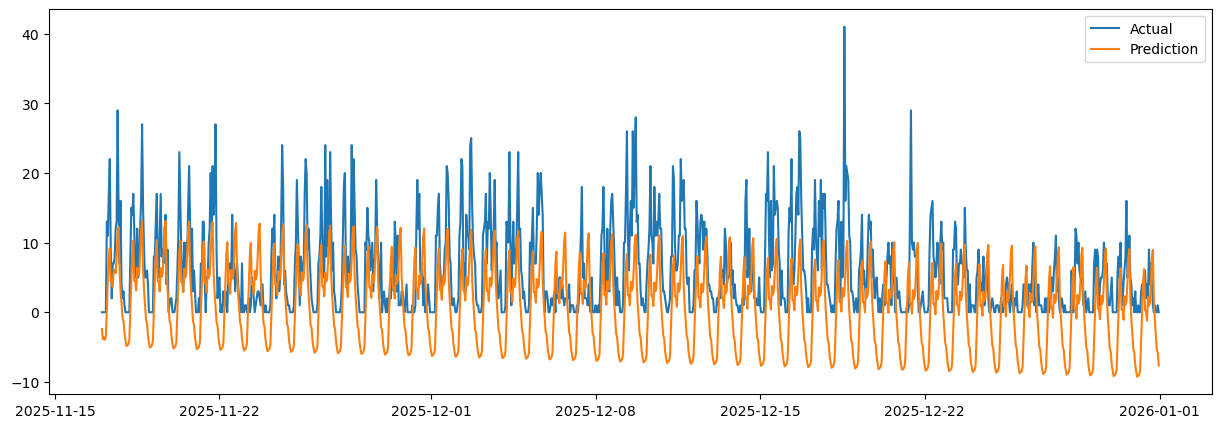

In [37]:
results_winter_v2 = execute_SARIMA(df_log1_IN_h_6M, (1,1,1), (1,1,1,24), 24 * 45)